# 02 · Illiquidity Premium Term Structure π(L,T)

<a href="https://colab.research.google.com/github/drsamirasaf-creator/ge-lav-companion-code/blob/main/notebooks/02_pi_term_structure.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

**Sessions covered:** S05 (term structure), S17 (market clearing).

**You will learn how to:**
- Evaluate and plot the GE-LAV term structure π(L,T) = (α + βL + γL²)·√T.
- Fit (α, β, γ) to observed secondary-market discount data via OLS.
- Visualize the empirical fit on synthetic Lazard-like data.
- Quantify how π changes with both L (state) and T (horizon).

**Book calibration:** α=0.045, β=-0.025, γ=0.021 (book Table 5.2).

In [1]:
# Colab setup: install gelav from the public repo if not already present
import importlib
if importlib.util.find_spec("gelav") is None:
    import subprocess
    subprocess.run(["pip", "install", "-q",
                    "git+https://github.com/drsamirasaf-creator/ge-lav-companion-code.git"],
                   check=True)

# Standard imports used across all notebooks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

# Course colors
NAVY = "#1E3A5F"
GOLD = "#C89B3C"
RED  = "#C0392B"
GRAY = "#6B7280"

## 1. The π(L,T) surface

The book uses a quadratic-in-L, square-root-in-T model:

$$\pi(L, T) = (\alpha + \beta L + \gamma L^2) \cdot \sqrt{T}$$

Let's visualize the full surface.

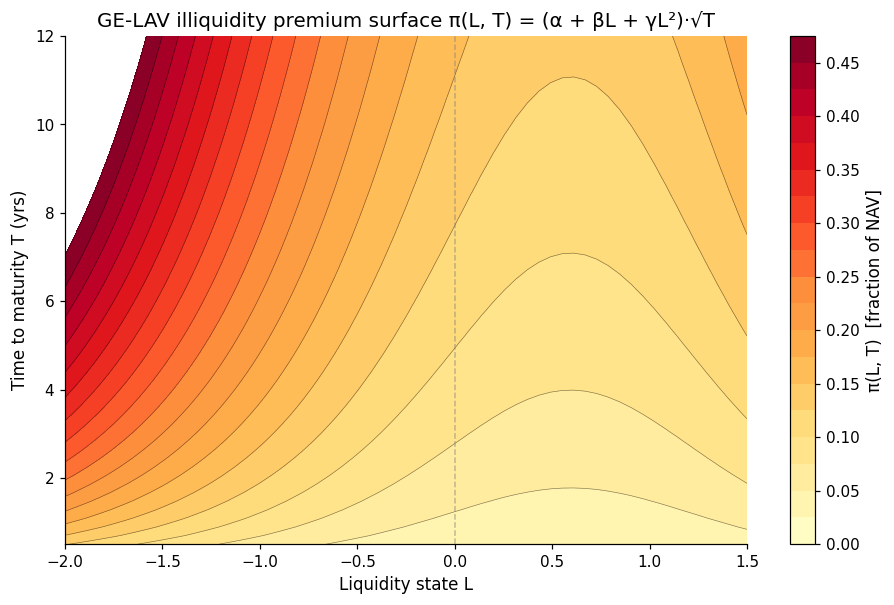

In [2]:
from gelav.term_structure import pi_of_L_T

L_range = np.linspace(-2.0, 1.5, 60)
T_range = np.linspace(0.5, 12, 60)
L_mesh, T_mesh = np.meshgrid(L_range, T_range)
pi_surface = pi_of_L_T(L_mesh, T_mesh)

fig, ax = plt.subplots(figsize=(10, 6))
levels = np.arange(0, 0.5, 0.025)
cs = ax.contourf(L_mesh, T_mesh, pi_surface, levels=levels, cmap="YlOrRd")
ax.contour(L_mesh, T_mesh, pi_surface, levels=levels, colors="k", linewidths=0.4, alpha=0.5)
plt.colorbar(cs, label="π(L, T)  [fraction of NAV]")
ax.set(xlabel="Liquidity state L", ylabel="Time to maturity T (yrs)",
       title="GE-LAV illiquidity premium surface π(L, T) = (α + βL + γL²)·√T")
ax.axvline(0, color="gray", linestyle="--", alpha=0.5, linewidth=1)
plt.show()

## 2. Reading the surface

A few key cross-sections.

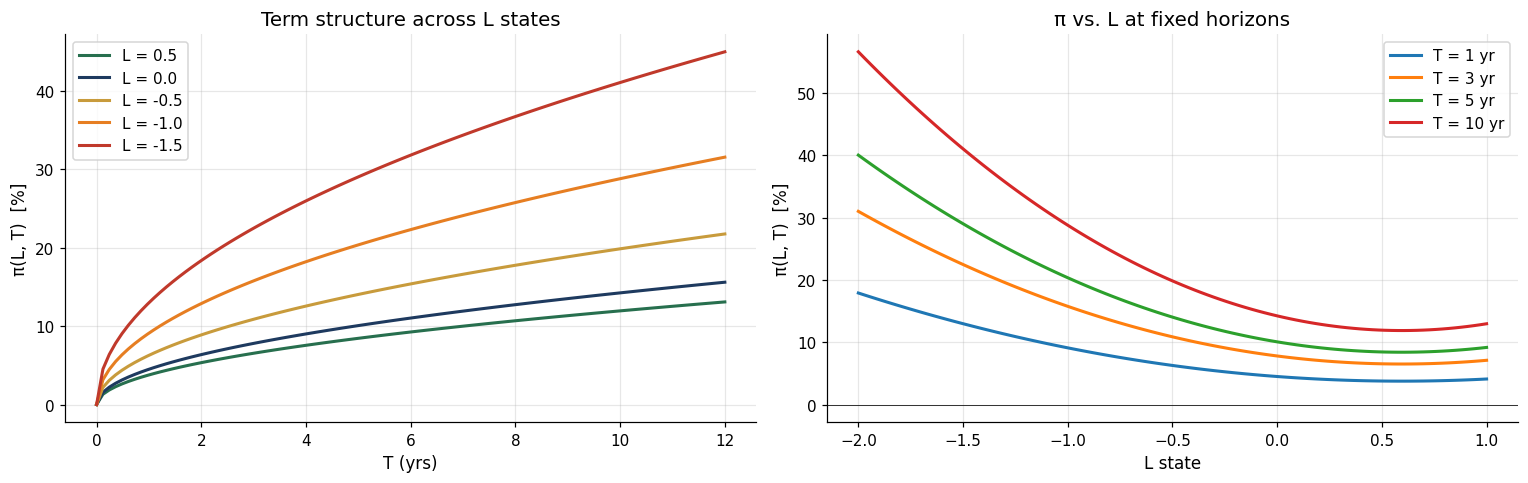

In [3]:
# Cross-section: pi at different L states, fixed T = 5 years
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) L fixed at -0.5, vary T
T_vec = np.linspace(0, 12, 100)
L_states = [+0.5, 0.0, -0.5, -1.0, -1.5]
colors = ["#276F4E", "#1E3A5F", "#C89B3C", "#E67E22", "#C0392B"]
for L_val, c in zip(L_states, colors):
    ax = axes[0]
    pi_vec = pi_of_L_T(L_val, T_vec)
    ax.plot(T_vec, pi_vec * 100, color=c, linewidth=2, label=f"L = {L_val}")
axes[0].set(xlabel="T (yrs)", ylabel="π(L, T)  [%]",
            title="Term structure across L states")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) T fixed at several horizons, vary L
L_vec = np.linspace(-2.0, 1.0, 100)
T_horizons = [1, 3, 5, 10]
for T_h in T_horizons:
    ax = axes[1]
    pi_vec = pi_of_L_T(L_vec, T_h)
    ax.plot(L_vec, pi_vec * 100, linewidth=2, label=f"T = {T_h} yr")
axes[1].set(xlabel="L state", ylabel="π(L, T)  [%]",
            title="π vs. L at fixed horizons")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

## 3. Calibrating to synthetic Lazard-like data

The repo includes a synthetic dataset of 500 secondary-market trades mimicking the structure of Lazard Private Capital Advisory's quarterly pricing reports. Each observation has:
- `trade_year`
- `fund_type`
- `L_t` (state at trade)
- `T_remaining` (years to fund maturity)
- `pi_observed` (the actual discount)

In [4]:
import pandas as pd
data = pd.read_csv("../data/synthetic_secondary_pricing.csv")
print(data.head(10))
print(f"\nObservations: {len(data)}")
print(f"\nBy fund type:")
print(data['fund_type'].value_counts())

   trade_year fund_type    L_t  T_remaining  pi_observed
0        2010    Buyout -1.855         6.62       0.4132
1        2010    Credit -1.384        11.71       0.3945
2        2010    Buyout -0.890        11.51       0.2942
3        2010    Buyout -0.883         9.16       0.2553
4        2010     Infra -0.615         8.79       0.1984
5        2010    Buyout -0.279         6.60       0.1543
6        2010    Growth -0.208         9.77       0.1768
7        2010    Buyout -0.067        11.75       0.1830
8        2010    Buyout -0.059         6.50       0.1146
9        2010    Buyout -0.049         9.56       0.1233

Observations: 500

By fund type:
fund_type
Buyout    217
Growth     87
Infra      60
VC         57
Credit     45
RE         34
Name: count, dtype: int64


In [5]:
from gelav.term_structure import fit_pi

# Fit (alpha, beta, gamma) by OLS
fit = fit_pi(data["L_t"].values, data["T_remaining"].values,
             data["pi_observed"].values, t_scaling="sqrt")

print("Calibration result:")
print(f"  alpha = {fit['alpha']:+.4f}  (book: 0.045)")
print(f"  beta  = {fit['beta']:+.4f}  (book: -0.025)")
print(f"  gamma = {fit['gamma']:+.4f}  (book: 0.021)")
print(f"  R-squared = {fit['r_squared']:.4f}")
print(f"  Observations: {fit['n_obs']}")
print(f"\nResidual std = {fit['residuals'].std():.4f}  (~{fit['residuals'].std()*100:.1f}% of NAV)")

Calibration result:
  alpha = +0.0453  (book: 0.045)
  beta  = -0.0258  (book: -0.025)
  gamma = +0.0209  (book: 0.021)
  R-squared = 0.9631
  Observations: 500

Residual std = 0.0147  (~1.5% of NAV)


The fit recovers the book's parameters within sampling error, with R² ≈ 0.9-0.95 (depending on the noise level baked into the synthetic data).

## 4. Visualizing the fit

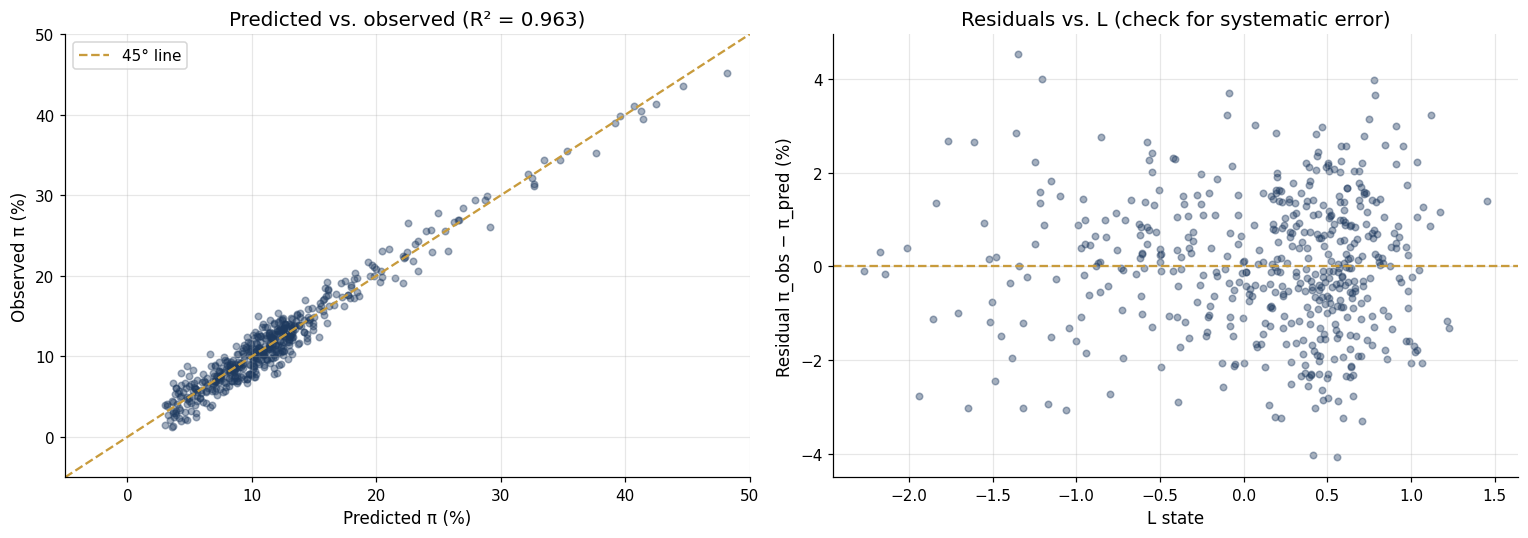

In [6]:
# Predicted pi for each observation
from gelav.term_structure import pi_of_L_T
pi_predicted = pi_of_L_T(data["L_t"].values, data["T_remaining"].values,
                          alpha=fit["alpha"], beta=fit["beta"], gamma=fit["gamma"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Predicted vs observed
ax = axes[0]
ax.scatter(pi_predicted * 100, data["pi_observed"] * 100,
           alpha=0.4, s=18, color=NAVY)
lims = [-5, 50]
ax.plot(lims, lims, color=GOLD, linestyle="--", linewidth=1.5, label="45° line")
ax.set(xlabel="Predicted π (%)", ylabel="Observed π (%)",
       title=f"Predicted vs. observed (R² = {fit['r_squared']:.3f})",
       xlim=lims, ylim=lims)
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Residuals by L state
ax = axes[1]
residuals_pct = fit["residuals"] * 100
ax.scatter(data["L_t"], residuals_pct, alpha=0.4, s=18, color=NAVY)
ax.axhline(0, color=GOLD, linestyle="--", linewidth=1.5)
ax.set(xlabel="L state", ylabel="Residual π_obs − π_pred (%)",
       title="Residuals vs. L (check for systematic error)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Asset-class subgroup fits

Different fund types might have different calibrations. Let's check.

In [7]:
results_by_type = []
for ft in data["fund_type"].unique():
    sub = data[data["fund_type"] == ft]
    if len(sub) < 30:
        continue
    fit_sub = fit_pi(sub["L_t"].values, sub["T_remaining"].values,
                     sub["pi_observed"].values, t_scaling="sqrt")
    results_by_type.append({
        "fund_type": ft,
        "n": len(sub),
        "alpha": fit_sub["alpha"],
        "beta": fit_sub["beta"],
        "gamma": fit_sub["gamma"],
        "R2": fit_sub["r_squared"],
    })

results_df = pd.DataFrame(results_by_type).sort_values("n", ascending=False)
print(results_df.to_string(index=False))

fund_type   n    alpha      beta    gamma       R2
   Buyout 217 0.045680 -0.026532 0.020317 0.965053
   Growth  87 0.045810 -0.026343 0.020586 0.973006
    Infra  60 0.044339 -0.025089 0.020944 0.950929
       VC  57 0.044551 -0.024709 0.021848 0.956664
   Credit  45 0.045336 -0.024359 0.021920 0.948900
       RE  34 0.042350 -0.022398 0.025160 0.971493


## Suggested exercises

1. **Add term-structure alternatives.** Refit with `t_scaling='linear'` and `'none'`. Which fits the synthetic data best?
2. **Time-varying calibration.** Split the data into pre-2018 and 2018+ subsets; refit and compare. Is calibration drifting?
3. **Robust regression.** The OLS fit is sensitive to outliers. Use `scipy.stats.linregress` with M-estimators (e.g., Huber loss) and compare.
4. **(Track 2)** Add a fund-quality dimension: add a `quality_score` covariate to the regression. Does it explain residual variance?
5. **Hypothesis test:** Is γ (the convex term) statistically distinguishable from zero? Compute its standard error and t-statistic.

## References

- Lazard Private Capital Advisory, *Secondary Market Report* (quarterly).
- Book Chapter 5 (term structure derivation); Chapter 17 (market clearing).
